In [35]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

# Randomly initialize weights
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y
    # y = a + b x + c x^2 + d x^3
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss
    loss = np.square(y_pred - y).sum()
    if t % 100 == 99:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')

99 5753.478350611708
199 3871.912456106577
299 2608.8901747387267
399 1760.3853097717094
499 1189.877477249446
599 805.9531811517505
699 547.3589538433132
799 373.0203643913559
899 255.37317615624877
999 175.90480930279418
1099 122.17162393045909
1199 85.80217821207765
1299 61.159601737500566
1399 44.44486087565165
1499 33.0951391045647
1599 25.37989205590869
1699 20.12940528374178
1799 16.552236383542038
1899 14.112328429872775
1999 12.446215513944647
Result: y = 0.046695919082515906 + 0.8168632454915963 x + -0.008055823065181489 x^2 + -0.08765814804170753 x^3


In [36]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [37]:
import torch
import math

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-1, 1, 2000, dtype=dtype)
y = torch.exp(x) # A Taylor expansion would be 1 + x + (1/2) x**2 + (1/3!) x**3 + ...

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

initial_loss = 1.
learning_rate = 1e-5
for t in range(5000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_pred - y).pow(2).sum()

    # Calculare initial loss, so we can report loss relative to it
    if t==0:
        initial_loss=loss.item()

    if t % 100 == 99:
        print(f'Iteration t = {t:4d}  loss(t)/loss(0) = {round(loss.item()/initial_loss, 6):10.6f}  a = {a.item():10.6f}  b = {b.item():10.6f}  c = {c.item():10.6f}  d = {d.item():10.6f}')

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')


Using cpu device
Iteration t =   99  loss(t)/loss(0) =   0.003675  a =   0.886852  b =   0.882764  c =   0.790334  d =   0.485187
Iteration t =  199  loss(t)/loss(0) =   0.001720  a =   0.927795  b =   0.845517  c =   0.725225  d =   0.437080
Iteration t =  299  loss(t)/loss(0) =   0.001092  a =   0.946582  b =   0.848361  c =   0.673883  d =   0.415894
Iteration t =  399  loss(t)/loss(0) =   0.000745  a =   0.960135  b =   0.856899  c =   0.636498  d =   0.399785
Iteration t =  499  loss(t)/loss(0) =   0.000541  a =   0.969991  b =   0.865803  c =   0.609305  d =   0.385292
Iteration t =  599  loss(t)/loss(0) =   0.000415  a =   0.977160  b =   0.874278  c =   0.589526  d =   0.371821
Iteration t =  699  loss(t)/loss(0) =   0.000333  a =   0.982375  b =   0.882229  c =   0.575140  d =   0.359231
Iteration t =  799  loss(t)/loss(0) =   0.000275  a =   0.986168  b =   0.889673  c =   0.564676  d =   0.347453
Iteration t =  899  loss(t)/loss(0) =   0.000233  a =   0.988927  b =   0.89663

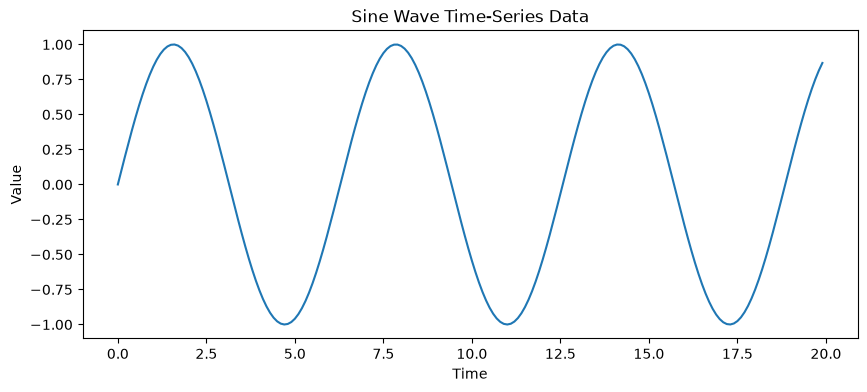

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sine wave
time = np.arange(0, 100, 0.1)
data = np.sin(time)

plt.figure(figsize=(10, 4))
plt.plot(time[:200], data[:200])
plt.title("Sine Wave Time-Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [39]:
import torch
from sklearn.model_selection import train_test_split

sequence_length = 20

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[i:i + sequence_length])
    y.append(data[i + sequence_length])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

X = torch.tensor(X).unsqueeze(-1)
y = torch.tensor(y).unsqueeze(-1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([980, 20, 1])
y shape: torch.Size([980, 1])


In [40]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # RNN output
        output, hidden = self.rnn(x)

        # IMPORTANT:
        # Select only the LAST time step
        last_output = output[:, -1, :]

        # Final prediction
        prediction = self.fc(last_output)

        return prediction

In [41]:
model = RNNModel(
    input_size=1,
    hidden_size=32,
    output_size=1
)

print(model)

RNNModel(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [42]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(model)

X_train shape: torch.Size([784, 20, 1])
y_train shape: torch.Size([784, 1])
RNNModel(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [43]:

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

epochs = 50

for epochcriterion = nn.MSELoss()
 in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(predictions, y_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}, "
            f"Loss: {loss.item():.6f}"
        )

SyntaxError: invalid syntax (3729196611.py, line 8)

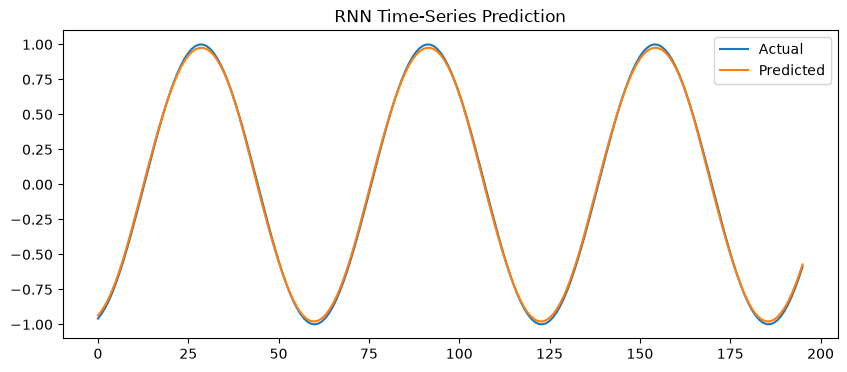

In [ ]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

predictions = predictions.numpy()
actual = y_test.numpy()

plt.figure(figsize=(10, 4))

plt.plot(actual[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.title("RNN Time-Series Prediction")
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # FIX: hidden_size is 64
        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        # Get output from the last time step
        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction


model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
lstm_model = LSTMModel()

lstm_model.eval()

with torch.no_grad():
    lstm_predictions = lstm_model(X_test)

print("X_test shape:", X_test.shape)
print("LSTM predictions shape:", lstm_predictions.shape)
print("y_test shape:", y_test.shape)

X_test shape: torch.Size([196, 20, 1])
LSTM predictions shape: torch.Size([196, 1])
y_test shape: torch.Size([196, 1])


In [ ]:
print("y_test:", y_test.shape)
print("RNN:", predictions.shape)
print("LSTM:", lstm_predictions.shape)

y_test: torch.Size([196, 1])
RNN: (196, 1)
LSTM: torch.Size([196, 1])


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.01
)

epochs = 50

for epoch in range(epochs):

    lstm_model.train()

    optimizer.zero_grad()

    predictions = lstm_model(X_train)

    loss = criterion(predictions, y_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}, "
            f"Loss: {loss.item():.6f}"
        )

Epoch 10, Loss: 0.094384
Epoch 20, Loss: 0.006614
Epoch 30, Loss: 0.005636
Epoch 40, Loss: 0.001697
Epoch 50, Loss: 0.000225


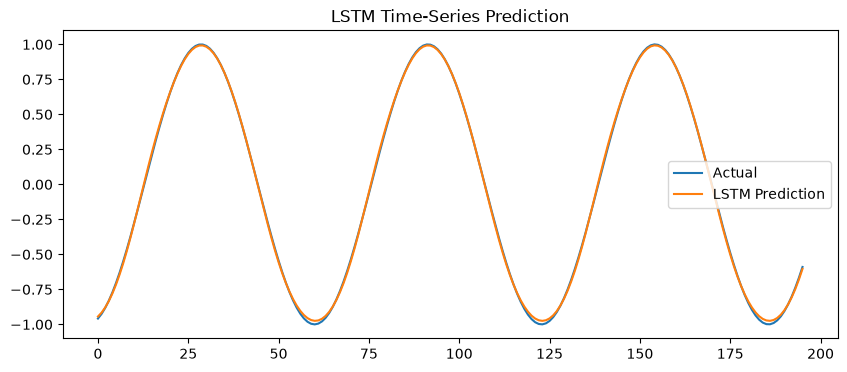

In [ ]:
lstm_model.eval()

with torch.no_grad():
    lstm_predictions = lstm_model(X_test)

lstm_predictions = lstm_predictions.numpy()

plt.figure(figsize=(10, 4))

plt.plot(y_test.numpy()[:200], label="Actual")
plt.plot(
    lstm_predictions[:200],
    label="LSTM Prediction"
)

plt.title("LSTM Time-Series Prediction")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# RNN Prediction
# =========================
model.eval()

with torch.no_grad():
    rnn_predictions = model(X_test)

rnn_pred = rnn_predictions.detach().cpu().numpy().reshape(-1)


# =========================
# LSTM Prediction
# =========================
lstm_model.eval()

with torch.no_grad():
    lstm_predictions = lstm_model(X_test)

lstm_pred = lstm_predictions.detach().cpu().numpy().reshape(-1)


# =========================
# True Values
# =========================
y_true = y_test.detach().cpu().numpy().reshape(-1)


# =========================
# Metrics
# =========================
rnn_mse = mean_squared_error(y_true, rnn_pred)
rnn_mae = mean_absolute_error(y_true, rnn_pred)

lstm_mse = mean_squared_error(y_true, lstm_pred)
lstm_mae = mean_absolute_error(y_true, lstm_pred)


print("===== RNN =====")
print(f"MSE: {rnn_mse:.6f}")
print(f"MAE: {rnn_mae:.6f}")

print("\n===== LSTM =====")
print(f"MSE: {lstm_mse:.6f}")
print(f"MAE: {lstm_mae:.6f}")

===== RNN =====
MSE: 0.489168
MAE: 0.632119

===== LSTM =====
MSE: 0.000125
MAE: 0.008928


In [1]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.5.0-cp311-cp311-win_amd64.whl.metadata (7.7 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp311-cp311-win_amd64.whl.metadata (8.8 kB)
  Using cached

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.


In [3]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject